In [1]:
!pip install albumentations -q

In [2]:
!pip install timm -U -q
!pip install urllib3==1.25.4 -q
!pip install boto3 -U -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
docker 6.1.3 requires urllib3>=1.26.0, but you have urllib3 1.25.4 which is incompatible.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
awscli 1.27.157 requires botocore==1.29.157, but you have botocore 1.31.3 which is incompatible.
sagemaker 2.167.0 requires PyYAML==6.0, but you have pyyaml 5.4.1 which is incompatible.


In [3]:
import albumentations as A
import albumentations.augmentations.functional as F

import copy
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import pickle
import timm
import torch
import torchvision as tv
import torch.nn as nn
import json
import boto3
from io import BytesIO
from io import StringIO
from urllib.parse import urlparse
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import GroupKFold, KFold
import gc
from sklearn.metrics import (
    accuracy_score, 
    confusion_matrix,
    f1_score, 
    precision_score, 
    recall_score,
    roc_auc_score
)
from torch.cuda.amp import GradScaler
from torch.cuda.amp import autocast
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

In [4]:
client = boto3.client("s3")

def list_all_objects_in_s3(bucketName, prefixName=None):
    """Get a list of objects in an S3 bucket path.
    @params:
    bucketName : s3 bucket 
    prefixName : s3 prefix to bucket
    returns : list of objects in s3 path
    [example of S3 bucket with prefix f"s3://{bucketName}/{prefix}"]
    """
    if prefixName:
        resp = client.list_objects_v2(Bucket=bucketName, StartAfter=prefixName)
    else:
        resp = client.list_objects_v2(Bucket=bucketName)
    list_of_files=[]
    for obj in resp['Contents']:
        files = bucketName+'/'+obj['Key']
        if prefixName:
            if prefixName in files:
                if prefixName!=files:
                    list_of_files.append(files)
        else:
            list_of_files.append(files)
    return list_of_files

def from_s3_npy(s3_uri: str):
    """
    @params 
    data : file content 
    s3_uri : s3 file path along with name [example of S3 bucket with prefix f"s3://{bucketName}/{prefix}/{fileName.npy}"]
    """
    try:
        bytes_ = BytesIO()
        parsed_s3 = urlparse(s3_uri)
        client.download_fileobj(
            Fileobj=bytes_, Bucket=parsed_s3.netloc, Key=parsed_s3.path[1:]
        )
        bytes_.seek(0)
        np_data=np.load(bytes_, allow_pickle=True)
    
    except Exception as e: # work on python 3.x
        print('Failed to read numpy array from S3: '+ str(e))
    return np_data

s3 = boto3.resource("s3")
def read_file_from_s3(bucket, file):
    try:
        obj = s3.Object(bucket, file)
        data = obj.get()["Body"]
        
    except Exception as e: # work on python 3.x
        print("Failed to read file from S3: "+ str(e))
    return data.read().decode(encoding="utf-8")

In [125]:
train = pd.read_csv(StringIO(read_file_from_s3("master-annotation-files", "train_annotations.csv")))
valid = pd.read_csv(StringIO(read_file_from_s3("master-annotation-files", "val_annotations.csv")))
test = pd.read_csv(StringIO(read_file_from_s3("master-annotation-files", "test_annotations.csv")))

In [12]:
#train = pd.read_csv("train_annotations.csv")
#valid = pd.read_csv("val_annotations.csv")
#test = pd.read_csv("test_annotations.csv")


In [126]:
train = train[train["sl"] <= 160]
valid = valid[valid["sl"] <= 160]
test = test[test["sl"] <= 160]

In [127]:
train.head()

,image_id,category_id,tissue_id,bbox,confidence,labeler,category,supercat_id,supercategory,tissues,file_name,msp_id,msp_file_name,scan_id,subject_id,split,sl,2d_bbox,yolo_bbox
0,31,3,1,"[330.0, 232.0, 54.0, 5.0, 19.0, 10.0]",3.0,1,Meniscal Tear (Radial),1,Meniscal Tear,Meniscus,MTR_104.h5,0000025_V00,0000025_V00.h5,MTR_104,25,train,54,"[232.0, 330.0, 19.0, 5.0]","[0.4716796875, 0.6494140625, 0.037109375, 0.00..."
1,31,3,1,"[330.0, 232.0, 54.0, 5.0, 19.0, 10.0]",3.0,1,Meniscal Tear (Radial),1,Meniscal Tear,Meniscus,MTR_104.h5,0000025_V00,0000025_V00.h5,MTR_104,25,train,55,"[232.0, 330.0, 19.0, 5.0]","[0.4716796875, 0.6494140625, 0.037109375, 0.00..."
2,31,3,1,"[330.0, 232.0, 54.0, 5.0, 19.0, 10.0]",3.0,1,Meniscal Tear (Radial),1,Meniscal Tear,Meniscus,MTR_104.h5,0000025_V00,0000025_V00.h5,MTR_104,25,train,56,"[232.0, 330.0, 19.0, 5.0]","[0.4716796875, 0.6494140625, 0.037109375, 0.00..."
3,31,3,1,"[330.0, 232.0, 54.0, 5.0, 19.0, 10.0]",3.0,1,Meniscal Tear (Radial),1,Meniscal Tear,Meniscus,MTR_104.h5,0000025_V00,0000025_V00.h5,MTR_104,25,train,57,"[232.0, 330.0, 19.0, 5.0]","[0.4716796875, 0.6494140625, 0.037109375, 0.00..."
4,31,3,1,"[330.0, 232.0, 54.0, 5.0, 19.0, 10.0]",3.0,1,Meniscal Tear (Radial),1,Meniscal Tear,Meniscus,MTR_104.h5,0000025_V00,0000025_V00.h5,MTR_104,25,train,58,"[232.0, 330.0, 19.0, 5.0]","[0.4716796875, 0.6494140625, 0.037109375, 0.00..."


In [128]:
train["image"] = train[["scan_id", "sl"]].astype(str).agg("_".join, axis=1)
valid["image"] = valid[["scan_id", "sl"]].astype(str).agg("_".join, axis=1)
test["image"] = test[["scan_id", "sl"]].astype(str).agg("_".join, axis=1)


In [130]:
train2 = train
valid2 = valid
test2 = test

In [131]:
train2 = pd.get_dummies(train.supercategory)
valid2 = pd.get_dummies(valid.supercategory)
test2 = pd.get_dummies(test.supercategory)

In [132]:
train = pd.concat([train, train2], axis=1)
valid = pd.concat([valid, valid2], axis=1)
test = pd.concat([test, test2], axis=1)

In [133]:
train_set = train.loc[:, ["image", "Cartilage Lesion", "Effusion", "Ligament Tear", "Meniscal Tear"]]
valid_set = valid.loc[:, ["image", "Cartilage Lesion", "Effusion", "Ligament Tear", "Meniscal Tear"]]
test_set = test.loc[:, ["image", "Cartilage Lesion", "Effusion", "Ligament Tear", "Meniscal Tear"]]

In [134]:
train_cv = pd.concat([train_set, valid_set])

In [135]:
train_cv.head()

,image,Cartilage Lesion,Effusion,Ligament Tear,Meniscal Tear
0,MTR_104_54,0,0,0,1
1,MTR_104_55,0,0,0,1
2,MTR_104_56,0,0,0,1
3,MTR_104_57,0,0,0,1
4,MTR_104_58,0,0,0,1


In [136]:
train_cv_no_effusion = train_cv.loc[:, ["image", "Cartilage Lesion", "Ligament Tear", "Meniscal Tear"]].reset_index()
train_cv_no_effusion = train_cv_no_effusion.drop("index", axis = 1)


In [137]:
train_cv_no_effusion["None of Above"] = np.where((train_cv_no_effusion["Cartilage Lesion"] == 0) & (train_cv_no_effusion["Ligament Tear"] == 0) & (train_cv_no_effusion["Meniscal Tear"] == 0), 1, 0)


In [138]:
train_cv_no_effusion.sum(axis = 0)

image               MTR_104_54MTR_104_55MTR_104_56MTR_104_57MTR_10...
Cartilage Lesion                                                 4112
Ligament Tear                                                     549
Meniscal Tear                                                    1743
None of Above                                                    4609
dtype: object

In [139]:
train_cv_no_effusion["Cartilage Lesion"] = train_cv_no_effusion["Cartilage Lesion"].astype("float")
train_cv_no_effusion["Ligament Tear"] = train_cv_no_effusion["Ligament Tear"].astype("float")
train_cv_no_effusion["Meniscal Tear"] = train_cv_no_effusion["Meniscal Tear"].astype("float")
train_cv_no_effusion["None of Above"] = train_cv_no_effusion["None of Above"].astype("float")

In [144]:
train_cv_no_effusion[(train_cv_no_effusion["Ligament Tear"] == 1) & (train_cv_no_effusion["Meniscal Tear"] == 1)]

,image,Cartilage Lesion,Ligament Tear,Meniscal Tear,None of Above


In [140]:
train_cv_no_effusion

,image,Cartilage Lesion,Ligament Tear,Meniscal Tear,None of Above
0,MTR_104_54,0.0,0.0,1.0,0.0
1,MTR_104_55,0.0,0.0,1.0,0.0
2,MTR_104_56,0.0,0.0,1.0,0.0
3,MTR_104_57,0.0,0.0,1.0,0.0
4,MTR_104_58,0.0,0.0,1.0,0.0
...,...,...,...,...,...
11008,MTR_045_117,1.0,0.0,0.0,0.0
11009,MTR_045_118,1.0,0.0,0.0,0.0
11010,MTR_045_119,1.0,0.0,0.0,0.0
11011,MTR_045_120,1.0,0.0,0.0,0.0


In [63]:
test_no_effusion = test_set.loc[:, ["image", "Cartilage Lesion", "Ligament Tear", "Meniscal Tear"]].reset_index()
test_no_effusion = test_no_effusion.drop("index", axis = 1)

In [64]:
test_no_effusion["None of Above"] = np.where((test_no_effusion["Cartilage Lesion"] == 0) & (test_no_effusion["Ligament Tear"] == 0) & (test_no_effusion["Meniscal Tear"] == 0), 1, 0)


In [65]:
test_no_effusion.sum(axis = 0)

image               MTR_173_20MTR_173_21MTR_173_22MTR_173_23MTR_17...
Cartilage Lesion                                                 1696
Ligament Tear                                                     306
Meniscal Tear                                                     691
None of Above                                                    2603
dtype: object

In [30]:
# Global variables
N_FOLDS = 5
MAX_LR = 2.0e-4
SAVE_CHECKPOINT_EVERY_STEP = 2000
CHECKPOINT_PATH = "/home/ec2-user/SageMaker/models"
PREDICT_MAX_BATCHES = 1e9
MAX_TRAIN_BATCHES = 10000
EPOCHS = 3
BACKBONE = "efficientnet_b1"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE == "cuda":
    BATCH_SIZE = 8
else:
    BATCH_SIZE = 2

In [42]:
# CV splits
split = GroupKFold(N_FOLDS)
for k, (_, test_idx) in enumerate(split.split(train_cv_no_effusion, groups=train_cv_no_effusion.image)):
    train_cv_no_effusion.loc[test_idx, "split"] = k
train_cv_no_effusion.sample(10)

,image,Cartilage Lesion,Ligament Tear,Meniscal Tear,None of Above,split
3937,MTR_150_95,1.0,0.0,0.0,0.0,2.0
3758,MTR_150_72,0.0,0.0,1.0,0.0,1.0
5129,MTR_232_75,1.0,0.0,0.0,0.0,3.0
7347,MTR_049_70,1.0,0.0,0.0,0.0,2.0
4426,MTR_183_109,1.0,0.0,0.0,0.0,1.0
3465,MTR_098_106,0.0,0.0,0.0,1.0,2.0
26,MTR_104_95,1.0,0.0,0.0,0.0,0.0
6720,MTR_236_91,0.0,0.0,1.0,0.0,1.0
2328,MTR_087_64,0.0,0.0,0.0,1.0,2.0
6311,MTR_230_115,0.0,0.0,1.0,0.0,4.0


In [33]:
from_s3_npy("s3://skm-dataset-echo1/MTR_104_58.npy")

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [44]:
class LesionDataset(torch.utils.data.Dataset):
    def __init__(self, df, transform=None):
        super().__init__()
        self.df = df
        self.transform = transform
        self.classes = ["Cartilage Lesion", "Ligament Tear", "Meniscal Tear", "None of Above"]
        
    def __getitem__(self, i):
        row = self.df.iloc[i]
        image_id = row.image
        img = from_s3_npy("s3://skm-dataset-echo1/" + image_id + ".npy")

        # Apply image transformations (if any)
        if self.transform is not None:
            x = self.transform(image=img)["image"]
        else:
            x = img

        # Labels
        y = torch.tensor(np.array([float(row[c]) for c in self.classes]), dtype=torch.float32)

        return x, y

    def __len__(self):
        return len(self.df)

In [45]:
# Image augmentations
train_transform = A.Compose([
    A.GaussianBlur((3, 7), p=0.25),
    A.RandomRotate90(p=0.25),
    A.OneOf([
        A.MotionBlur(p=0.2),
        A.Blur(blur_limit=3, p=0.1),
    ], p=0.5),
    A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.2, rotate_limit=45, interpolation=cv2.INTER_LINEAR, border_mode=cv2.BORDER_CONSTANT, p=0.25),
    A.OneOf([
        A.OpticalDistortion(p=0.3),
        A.GridDistortion(p=0.1),
    ], p=0.25),
    ToTensorV2(p=1.0)
])

valid_transform = A.Compose([
    ToTensorV2(p=1.0)
])

In [46]:
# Check the dataset outputs
dataset_train = LesionDataset(train_cv_no_effusion, train_transform)
x, y = dataset_train[500]
print(x.shape, y.shape)

torch.Size([1, 512, 512]) torch.Size([4])


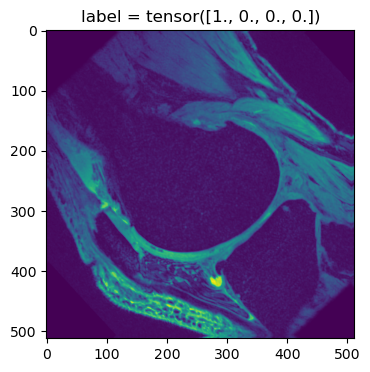

In [47]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(4, 4))
ax.imshow(np.transpose(x, (1, 2, 0)))
ax.set_title(f"label = {y}")
plt.show()

In [48]:
# Custom model class
class LesionModel(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.model = timm.create_model(backbone, pretrained=True, in_chans=1, num_classes=4)

    def forward(self, x):
        x = self.model(x)
        return x

In [49]:
# Quick test of the model
model = LesionModel(BACKBONE)
print(model(torch.randn(1, 1, 512, 512)))
del model

tensor([[-0.9838,  0.4541,  0.3636, -1.8153]], grad_fn=<AddmmBackward0>)


In [83]:
def gc_collect():
    """Performs garbage removal after memory-intensive operations."""
    gc.collect()
    torch.cuda.empty_cache()
    
def load_model(model, path, device="cpu"):
    """Loads a model from a specified location.

    Args:
        model: An instance of the model class to load.
        path: A path to load model weights from.
        device: A device to place the model onto.

    Returns:
        model: The model with the loaded weights.
    """
    weights = torch.load(os.path.join(path), map_location=device)
    model.load_state_dict(weights)
    return model

def save_model(model, path):
    """Saves a model.

    Args:
        model: The model to save.
        path: The path to the saved model file.
    """
    torch.save(model.state_dict(), path)

def get_top_k_metrics(y_true, y_pred, k):
    """Retrieves the top-n predictions.

    Args:
        y_true: An array of the true sample labels.
        y_pred: An array of the predicted sample probabilities.
        k: The number of top class probabilities to consider.
    Returns:
        metrics: A dict of top-k metrics (accuracy, precision, recall, f1, confusion matrix)
    """
    y_true_labels = np.argmax(y_true, axis=1)
    sorted_pred = np.argsort(y_pred, axis=1, kind="mergesort")[:, ::-1][:, :k]
    hits = (y_true_labels == sorted_pred.T).any(axis=0).astype(np.uint8)
    accuracy = hits.mean()
    tp = np.array([hits[y_true_labels == i].sum() for i in range(4)])
    fn = np.array([((y_true_labels == i) & np.logical_not((sorted_pred == i).any(axis=1))).sum() for i in range(4)])
    fp = np.array([((y_true_labels != i) & (hits == 0) & (sorted_pred == i).any(axis=1)).sum() for i in range(4)])
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    f1 = 2.0 * precision * recall / (precision + recall)
    cm = np.array([[((y_true_labels == i) & (sorted_pred == j).any(axis=1)).sum() for j in range(4)] for i in range(4)])
    metrics = {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "confusion_matrix": cm 
    }
    return metrics


def evaluate_classification_model(
    model, 
    dataset, 
    max_batches, 
    device="cpu", 
    batch_size=2,
    shuffle=False
):
    """Evaluates a lesion classification model against a dataset.

    Args:
        model: A model to be evaluated.
        dataset: A dataset object containing images to evaluate the model with.
        max_batches: The number of batches to run the evaluation loop for. If the number of
            iterations exceeds max_batches, the loop will terminate.
        device: A device to run the evaluation loop on.
        batch_size: The number of images to process at the same time.
        shuffle: A boolean signifying whether or not to shuffle the dataset.

    Returns:
        loss: The average cross-entropy loss across all images in the dataset.
        roc_auc: The average ROC AUC score across all classes and images in the dataset.
        f1: The average F1 score across all classes and images in the dataset.
    """
    torch.manual_seed(42)
    model = model.to(device)
    model.eval()
    loader_test = torch.utils.data.DataLoader(
        dataset, 
        batch_size=batch_size, 
        shuffle=shuffle, 
        num_workers=os.cpu_count()
    )
    y_true = []
    y_pred = []
    total_loss = 0.0
    n = 0
    with torch.no_grad():
        with tqdm(loader_test) as loader_:
            for i, (x, y) in enumerate(loader_):
                x = x.to(device, dtype=torch.float)
                y = y.to(device)
                logits = model(x)
                loss = nn.CrossEntropyLoss()(logits, y.float())
                y_pred.append(torch.nn.functional.softmax(logits, dim=-1).cpu().numpy())
                y_true.append(y.cpu().numpy())
                total_loss += loss.item() * x.size(0)
                n += x.size(0)
                loader_.set_description(f"loss = {total_loss / n:.04f}")
                if i >= max_batches:
                    break
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    loss = total_loss / n
    roc_auc = roc_auc_score(y_true, y_pred, multi_class="ovr", average="macro")
    print("\n\n[EVALUATION METRICS]")
    print(f"Loss: {loss:.04f}")
    print(f"ROC AUC: {roc_auc:.04f}\n")
    for k in range(1, 3):
        metrics = get_top_k_metrics(y_true, y_pred, k)
        print(f"[k = {k}]")
        print(f"F1: {metrics['f1'].mean():.04f}")
        print(f"Precision: {metrics['precision'].mean():.04f}")
        print(f"Recall: {metrics['recall'].mean():.04f}")
        print(f"Accuracy: {metrics['accuracy'].mean():.04f}")
        if k == 1:
            cm = pd.DataFrame(metrics["confusion_matrix"], index=dataset.classes, columns=dataset.classes)
            print(f"Confusion Matrix:\n{cm}")
        print()
    return loss

def train_classification_model(
    model,
    dataset_train,
    dataset_valid,
    path,
    class_weights=None,
    batch_size=2,
    device="cpu",
    epochs=1,
    max_lr=2.0e-4
):
    """Trains a classification model.

    Args:
        model: The model to train.
        dataset_train: A training dataset.
        dataset_valid: A validation dataset.
        path: A path to save the model to.
        class_weights: The relative weight of each lesion class when computing the cross-entropy loss.
        batch_size: The number of images to process at the same time.
        device: A device to run the training loop on.

    Returns:
        model: The best model from the training loop.
    """
    torch.manual_seed(42)
    loader_train = torch.utils.data.DataLoader(
        dataset_train, 
        batch_size=batch_size, 
        shuffle=True, 
        num_workers=os.cpu_count(),
        pin_memory=True,
        timeout=120
    )
    optim = torch.optim.RAdam(model.parameters())
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optim, 
        max_lr=max_lr, 
        epochs=epochs,
        steps_per_epoch=len(loader_train),
        pct_start=0.3
    )
    model.train()
    if class_weights is not None:
        class_weights = torch.tensor(class_weights).to(device)
    scaler = GradScaler()
    best_loss = float("inf")
    best_model = copy.deepcopy(model)
    for epoch in range(epochs):
        print(f"[EPOCH {epoch + 1}/{epochs}]")
        with tqdm(loader_train) as loader_:
            total_loss = 0.0
            n = 0
            for i, (x, y) in enumerate(loader_):
                optim.zero_grad()
                with autocast():
                    x = x.to(device, dtype=torch.float)
                    y = y.to(device)
                    logits = model(x)
                    loss = nn.CrossEntropyLoss(weight=class_weights)(logits, y.float())
                    if np.isinf(loss.item()) or np.isnan(loss.item()):
                        print(f"Bad loss, skipping batch {i}")
                        del loss
                        gc_collect()
                        continue
                scaler.scale(loss).backward()
                scaler.step(optim)
                scaler.update()
                scheduler.step()
                total_loss += loss.item() * x.size(0)
                n += x.size(0)
                loader_.set_description(f"loss = {total_loss / n :.04f}")
        loss = evaluate_classification_model(
            model, 
            dataset_valid, 
            max_batches=10000, 
            device=device, 
            batch_size=batch_size,
            shuffle=False
        )
        if loss < best_loss: 
            save_model(model, path)
            best_loss = loss
            best_model = copy.deepcopy(model)
    return best_model

def predict_lesion(x, y, model, device, verbose=True):
    """Predicts the lesion class for a given image.

    Args:
        x: An image to predict lesions for.
        y: The true label for the image.
        model: A model to use to make predictions.
        device: A device to evaluate on.
        verbose: A boolean flag indicating whether or not to display additional information.
    """
    x = x.to(device, dtype=torch.float)[None, :]
    y = y.to(device)[None, :]
    model = model.to(device)
    model.eval()
    with torch.no_grad():
        logits = model(x)
        loss = nn.CrossEntropyLoss()(logits, y.float())
        y_pred = torch.nn.functional.softmax(logits, dim=-1)[0]
        loss += loss.item()
    if verbose:
        fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(4, 4))
        ax.imshow(np.transpose(x[0].cpu().numpy(), (1, 2, 0)))
        print(f"y_true = {y.cpu().numpy()[0]}")
        print(f"y_pred = {np.around(y_pred.cpu().numpy(), 3)}")


def visualize_features(x, y, model, device, k=1):
    """Visualizes the learned kernel features of a CNN model.

    Args:
        x: An image to predict lesions for.
        y: The true label for the image.
        model: A model to use to make predictions.
        device: A device to evaluate on.
    """
    x = x.to(device, dtype=torch.float)[None, :]
    y = y.to(device)[None, :]
    model = model.to(device)
    model.eval()
    with torch.no_grad():
        layers = list(model.model.children())
        f = x
        for i in range(k):
            layer = layers[i]
            f = layer(f)
    fig, axs = plt.subplots(nrows=8, ncols=4, figsize=(4 * 4, 8 * 4))
    for i in range(8):
        for j in range(4):
            ax = axs[i, j]
            ax.imshow(f[0, i + j].cpu().numpy())
            ax.set_title(i + j)

In [56]:
dataset_train = LesionDataset(train_cv_no_effusion.query("split != @fold"), train_transform)

In [57]:
len(dataset_train)

8810

In [60]:
# Training loop
classification_models = []
for fold in range(N_FOLDS):
    print(f"[FOLD {fold + 1}/{N_FOLDS}]")
    path = os.path.join(CHECKPOINT_PATH, f"efficientnetb1-f{fold}.tph")
    # Load the models if they already exist
    if os.path.exists(path):
        print(f"Found cached version of {path}")
        classification_models.append(load_model(LesionModel(BACKBONE), path, DEVICE))
    else:
        gc_collect()
        dataset_train = LesionDataset(train_cv_no_effusion.query("split != @fold"), train_transform)
        dataset_valid = LesionDataset(train_cv_no_effusion.query("split == @fold"), valid_transform)
        model = LesionModel(BACKBONE).to(DEVICE)
        classification_models.append(
            train_classification_model(
                model,
                dataset_train,
                dataset_valid,
                path,
                class_weights=None,
                batch_size=BATCH_SIZE,
                device=DEVICE,
                epochs=EPOCHS,
                max_lr=MAX_LR
            )
        )

[FOLD 1/5]
[EPOCH 1/3]


loss = 3.1252:  13%|█▎        | 144/1102 [00:22<02:15,  7.08it/s]

Bad loss, skipping batch 144


loss = 2.6197:  28%|██▊       | 304/1102 [00:45<01:52,  7.11it/s]

Bad loss, skipping batch 304


...

Bad loss, skipping batch 308


loss = 2.5499:  31%|███       | 337/1102 [00:50<01:48,  7.05it/s]

Bad loss, skipping batch 337


loss = 2.1063:  52%|█████▏    | 575/1102 [01:24<01:17,  6.79it/s]


RuntimeError: Caught RuntimeError in DataLoader worker process 15.
Original Traceback (most recent call last):
  File "/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/torch/utils/data/_utils/worker.py", line 308, in _worker_loop
    data = fetcher.fetch(index)
  File "/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/torch/utils/data/_utils/fetch.py", line 54, in fetch
    return self.collate_fn(data)
  File "/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/torch/utils/data/_utils/collate.py", line 264, in default_collate
    return collate(batch, collate_fn_map=default_collate_fn_map)
  File "/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/torch/utils/data/_utils/collate.py", line 142, in collate
    return [collate(samples, collate_fn_map=collate_fn_map) for samples in transposed]  # Backwards compatibility.
  File "/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/torch

In [66]:
test_no_effusion

,image,Cartilage Lesion,Ligament Tear,Meniscal Tear,None of Above
0,MTR_173_20,0,0,0,1
1,MTR_173_21,0,0,0,1
2,MTR_173_22,0,0,0,1
3,MTR_173_23,0,0,0,1
4,MTR_173_24,0,0,0,1
...,...,...,...,...,...
5291,MTR_158_137,0,0,0,1
5292,MTR_158_138,0,0,0,1
5293,MTR_158_139,0,0,0,1
5294,MTR_158_140,0,0,0,1


In [71]:
model = load_model(LesionModel(BACKBONE), "models_0716/efficientnetb1-f4.tph").to(DEVICE)

In [72]:
dataset_test = LesionDataset(test_no_effusion, valid_transform)


In [119]:
i = np.argwhere(test_no_effusion["Ligament Tear"].values == 1.0)[100][0]

In [120]:
x, y = dataset_test[i]

y_true = [0. 1. 0. 0.]
y_pred = [0.702 0.151 0.01  0.138]


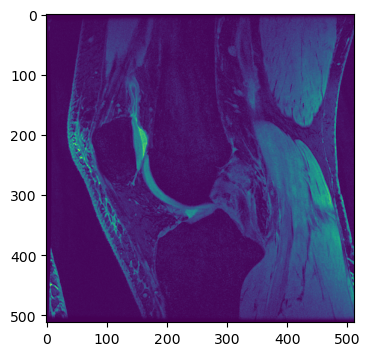

In [121]:
predict_lesion(x, y, model, DEVICE)


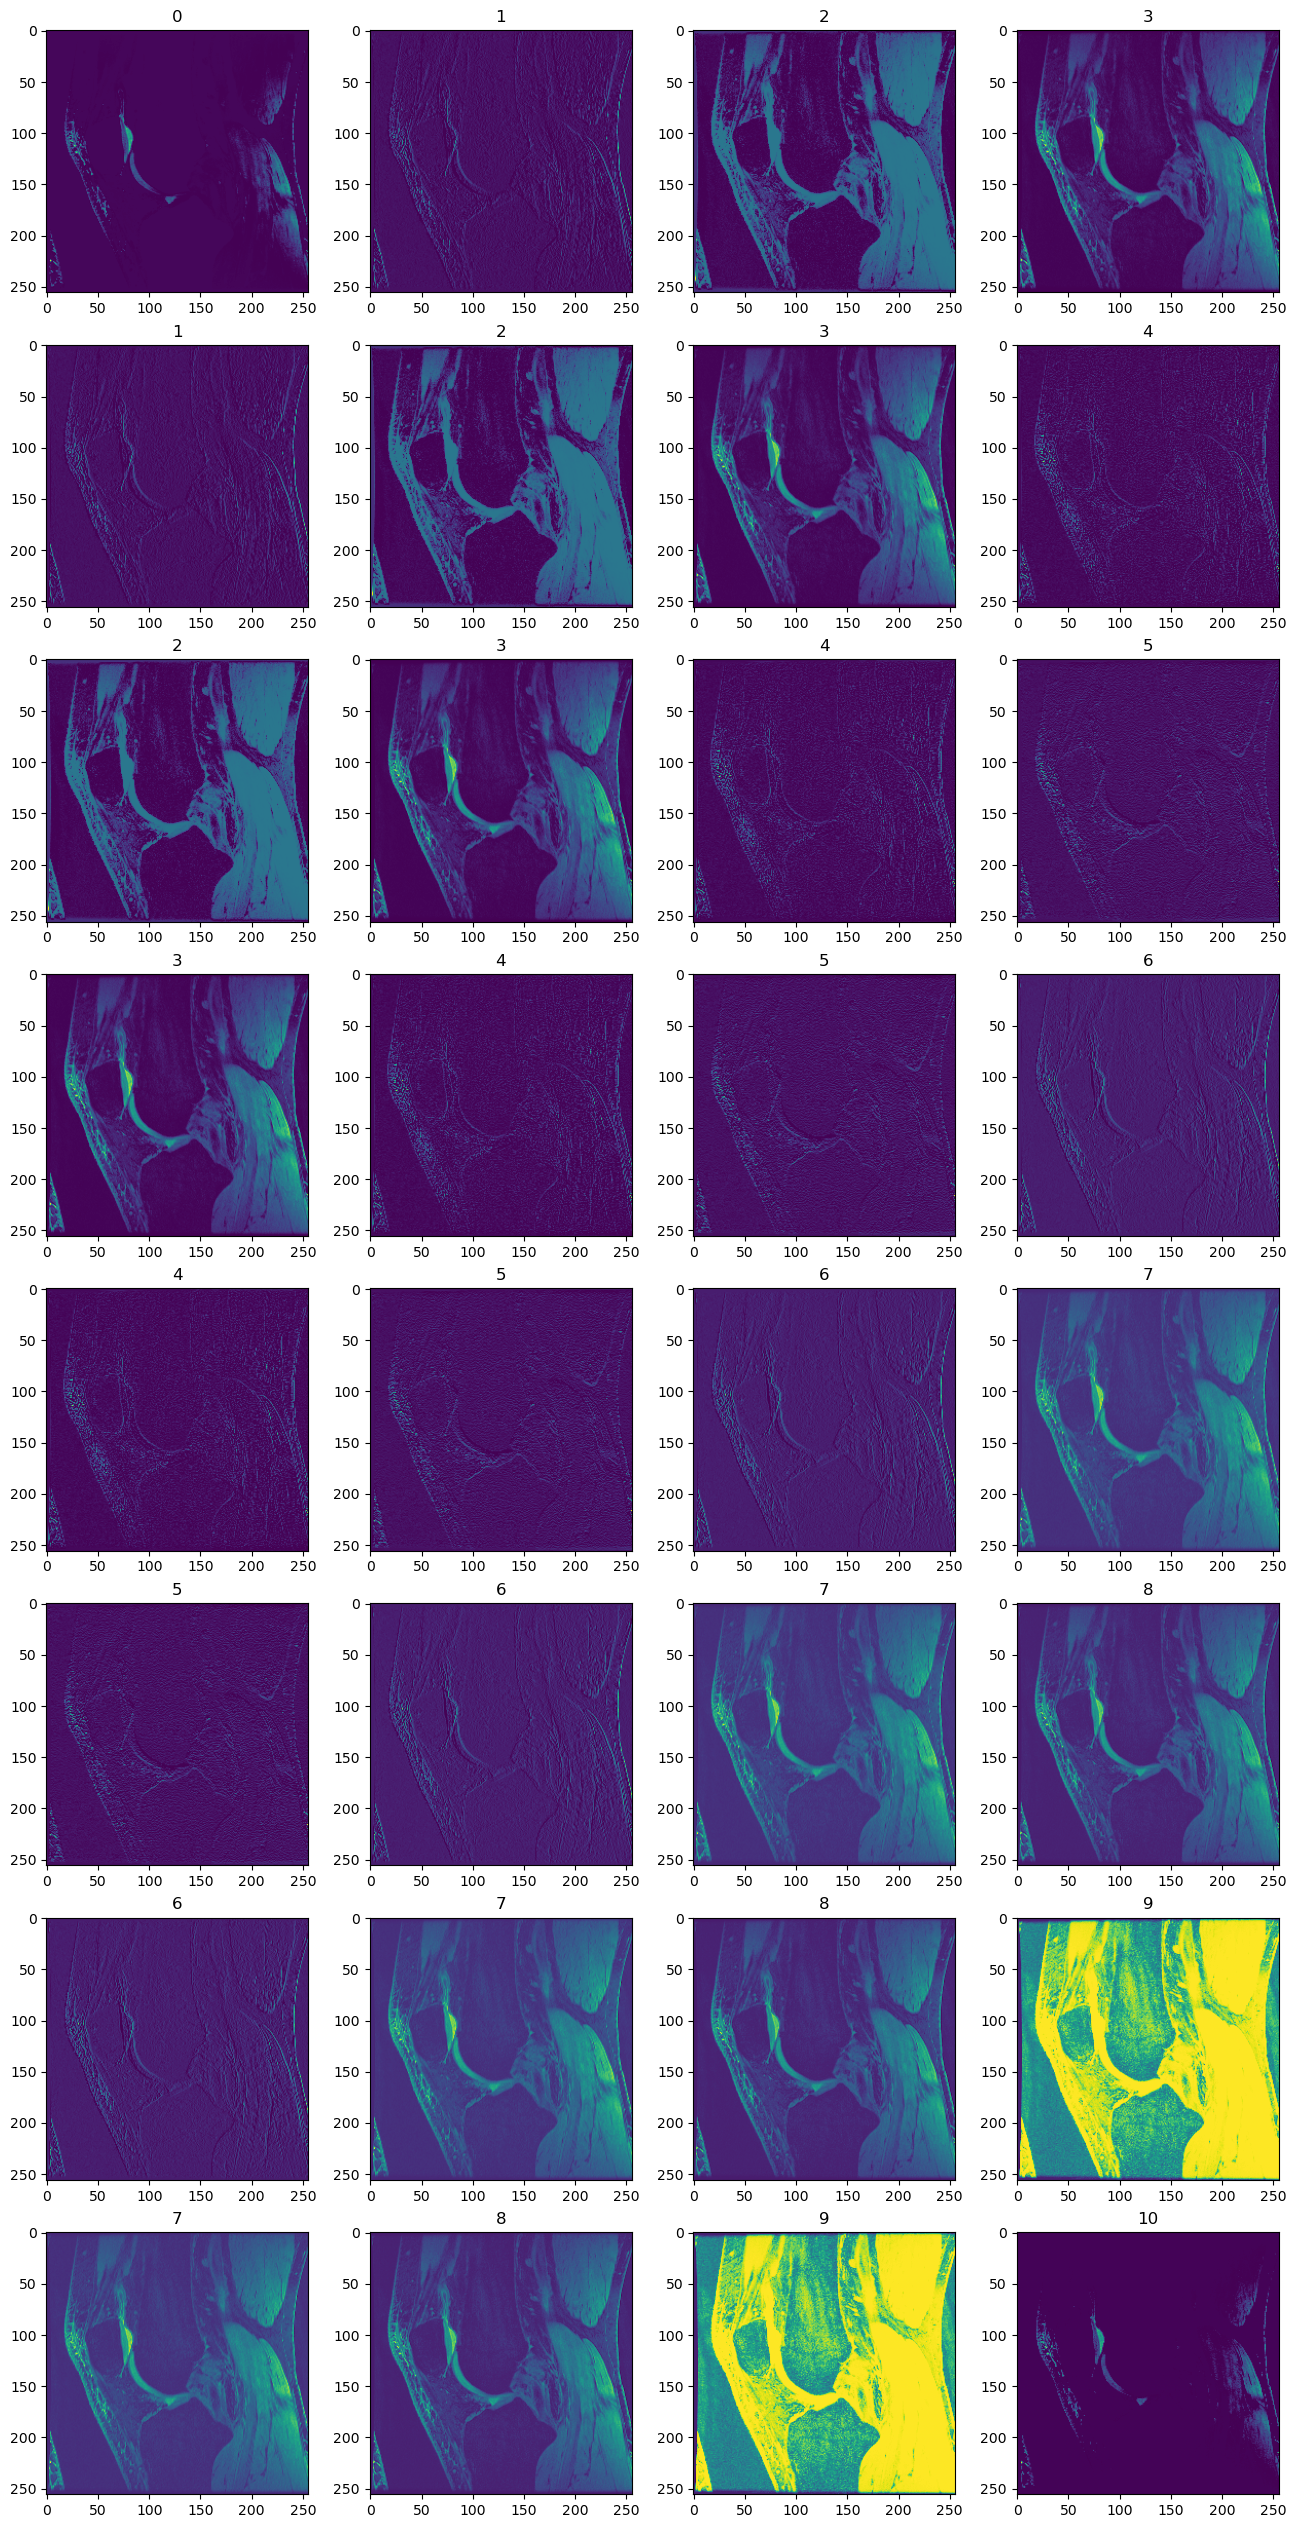

In [124]:
visualize_features(x, y, model, DEVICE, k=2)